In [72]:
import math
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pulp import LpMaximize, LpProblem, LpVariable, lpSum, LpBinary, PULP_CBC_CMD
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

print("✓ All packages imported successfully")


✓ All packages imported successfully


In [73]:
WAREHOUSE_W = 88.0  # feet
WAREHOUSE_H = 48.0  # feet

# Shipping door location
DOOR_X_MIN = 25.0
DOOR_X_MAX = 37.0
DOOR_Y = 48.0

# Current shelf layout: name: (xmin, xmax, ymin, ymax, type)
current_shelves = {
    "LargeA": (77.0, 88.0, 0.0, 36 + 2/12.0, "large"),
    "LargeB": (57 + 4/12.0, 66 + 4/12.0, 0.0, 29.0, "large"),
    "Small1": (24 + 4/12.0, 27 + 10/12.0, 0.0, 26.0, "small"),
    "Small2": (37 + 4/12.0, 40 + 10/12.0, 0.0, 26.0, "small"),
    "Small3": (40 + 10/12.0, 44 + 4/12.0, 0.0, 26.0, "small"),
    "Small4": (53 + 10/12.0, 57 + 4/12.0, 0.0, 26.0, "small"),
}

# Scoring parameters
TYPE_BASE = {'large': 40.0, 'small': 25.0}
FACE_LOSS_PENALTY = 20.0  # Penalty for two-sided shelves touching walls
ACCESS_SCALE = 100.0       # Accessibility scoring weight

# Grid generation for candidate positions
GRID_STEP = 2.0  # feet (smaller = more positions but slower solving)

# CONSTRAINTS
MIN_SHELF_SPACING = 8.0  # feet - minimum distance between any two shelves
DOOR_CLEARANCE_Y = 9.0   # feet - clearance in front of door (Y direction)
DOOR_CLEARANCE_X = 6.0   # feet - clearance to sides of door (X direction)
FORBIDDEN_ZONE_CLEARANCE = 8.0  # feet - minimum clearance from forbidden zones
REQUIRE_WALL_TOUCH = True # If True, each shelf must touch at least one wall
FORBIDDEN_ZONE = [(77.0, 88.0, 37.0, 48.0)]  # Office area

print("✓ Configuration loaded")
print(f"  Warehouse: {WAREHOUSE_W}' x {WAREHOUSE_H}'")
print(f"  Shelves: {len(current_shelves)}")
print(f"  Grid step: {GRID_STEP} feet")
print(f"\n✓ Practical constraints enabled:")
print(f"  Min shelf spacing: {MIN_SHELF_SPACING} feet")
print(f"  Door clearance: {DOOR_CLEARANCE_Y}' (front) x {DOOR_CLEARANCE_X}' (sides)")
print(f"  Forbidden zone clearance: {FORBIDDEN_ZONE_CLEARANCE} feet")
print(f"  Must touch wall: {REQUIRE_WALL_TOUCH}")


✓ Configuration loaded
  Warehouse: 88.0' x 48.0'
  Shelves: 6
  Grid step: 2.0 feet

✓ Practical constraints enabled:
  Min shelf spacing: 8.0 feet
  Door clearance: 9.0' (front) x 6.0' (sides)
  Forbidden zone clearance: 8.0 feet
  Must touch wall: True


In [74]:
def center_from_rect(x1, x2, y1, y2):
    """Calculate center point of rectangle."""
    return ((x1 + x2)/2.0, (y1 + y2)/2.0)

def min_dist_to_door(cx, cy):
    """Calculate minimum distance from point to shipping door."""
    if cx < DOOR_X_MIN:
        dx = DOOR_X_MIN - cx
    elif cx > DOOR_X_MAX:
        dx = cx - DOOR_X_MAX
    else:
        dx = 0.0
    dy = abs(DOOR_Y - cy)
    return math.hypot(dx, dy)

def touches_wall_rect(x1, x2, y1, y2):
    """Check which walls a rectangle touches."""
    left = x1 <= 0.001
    right = x2 >= WAREHOUSE_W - 0.001
    bottom = y1 <= 0.001
    top = y2 >= WAREHOUSE_H - 0.001
    return left, right, bottom, top

def access_score_from_center(cx, cy):
    """Calculate accessibility score based on distance to door."""
    d = min_dist_to_door(cx, cy)
    return ACCESS_SCALE / (1.0 + d)

def compute_value_score(shelf_name, x1, x2, y1, y2, shelf_type):
    """Compute total value score for a shelf placement."""
    cx, cy = center_from_rect(x1, x2, y1, y2)
    base = TYPE_BASE.get(shelf_type, 20.0)
    access = access_score_from_center(cx, cy)
    
    left, right, bottom, top = touches_wall_rect(x1, x2, y1, y2)
    loses_face = False
    if shelf_type in ('large',):
        if left or right or top or bottom:
            loses_face = True
    
    penalty = FACE_LOSS_PENALTY if loses_face else 0.0
    total_score = base + access - penalty
    
    return round(total_score, 2), round(min_dist_to_door(cx, cy), 2), loses_face

def overlaps_forbidden_zone(x1, x2, y1, y2):
    """Check if a shelf position overlaps with any forbidden zone."""
    for zone in FORBIDDEN_ZONE:
        zone_x1, zone_x2, zone_y1, zone_y2 = zone
        if not (x2 <= zone_x1 or x1 >= zone_x2 or y2 <= zone_y1 or y1 >= zone_y2):
            return True
    return False

def overlaps_forbidden_zone(x1, x2, y1, y2, clearance=0.0):
    """Check if a shelf position overlaps with or is too close to any forbidden zone.
    
    Args:
        x1, x2, y1, y2: Shelf coordinates
        clearance: Minimum distance to maintain from forbidden zones
    
    Returns:
        Boolean: True if shelf violates forbidden zone constraints
    """
    for zone in FORBIDDEN_ZONE:
        zone_x1, zone_x2, zone_y1, zone_y2 = zone
        
        # Expand zone by clearance amount
        expanded_x1 = zone_x1 - clearance
        expanded_x2 = zone_x2 + clearance
        expanded_y1 = zone_y1 - clearance
        expanded_y2 = zone_y2 + clearance
        
        # Check if shelf overlaps with expanded zone
        if not (x2 <= expanded_x1 or x1 >= expanded_x2 or 
                y2 <= expanded_y1 or y1 >= expanded_y2):
            return True
    return False

def generate_positions_for_dim(length, depth, step=None, allow_rotation=True):
    """Generate all valid candidate positions for a shelf of given dimensions.
    
    Args:
        length: Shelf length (x-dimension)
        depth: Shelf depth (y-dimension)
        step: Grid step size
        allow_rotation: If True, generate both 0° and 90° rotations
    
    Returns:
        List of tuples: (x1, x2, y1, y2, rotation_degrees)
    """
    if step is None:
        step = GRID_STEP
    
    positions = []
    
    # Generate positions for both orientations
    orientations = [(length, depth, 0)]  # 0° rotation
    if allow_rotation and abs(length - depth) > 0.1:  # Don't duplicate if square
        orientations.append((depth, length, 90))  # 90° rotation
    
    for width, height, rotation in orientations:
        max_x_start = int((WAREHOUSE_W - width) // step)
        max_y_start = int((WAREHOUSE_H - height) // step)
        
        starts_x = [round(i*step, 3) for i in range(0, max_x_start+1)]
        starts_y = [round(i*step, 3) for i in range(0, max_y_start+1)]
        
        for sx in starts_x:
            x1 = sx
            x2 = round(sx + width, 3)
            for sy in starts_y:
                y1 = sy
                y2 = round(sy + height, 3)
                
                # Don't block shipping door
                if (x1 < DOOR_X_MAX and x2 > DOOR_X_MIN) and (y2 >= DOOR_Y - 0.5):
                    continue
                
                # Door clearance zone
                door_zone_x_min = DOOR_X_MIN - DOOR_CLEARANCE_X
                door_zone_x_max = DOOR_X_MAX + DOOR_CLEARANCE_X
                door_zone_y_min = DOOR_Y - DOOR_CLEARANCE_Y
                
                if (x2 > door_zone_x_min and x1 < door_zone_x_max and 
                    y2 > door_zone_y_min and y1 < DOOR_Y):
                    continue
                
                # Must touch at least one wall
                if REQUIRE_WALL_TOUCH:
                    left, right, bottom, top = touches_wall_rect(x1, x2, y1, y2)
                    if not (left or right or bottom or top):
                        continue
                
                # Check forbidden zones with clearance
                if overlaps_forbidden_zone(x1, x2, y1, y2, clearance=FORBIDDEN_ZONE_CLEARANCE):
                    continue
                
                positions.append((x1, x2, y1, y2, rotation))
    
    return positions

def min_distance_between_shelves(pos1, pos2):
    """Calculate minimum distance between two shelf rectangles (edge-to-edge).
    
    Args:
        pos1: Tuple (x1, x2, y1, y2) or (x1, x2, y1, y2, rotation)
        pos2: Tuple (x1, x2, y1, y2) or (x1, x2, y1, y2, rotation)
    
    Returns:
        Float: Minimum edge-to-edge distance
    """
    # Handle both formats (with and without rotation)
    ax1, ax2, ay1, ay2 = pos1[0], pos1[1], pos1[2], pos1[3]
    bx1, bx2, by1, by2 = pos2[0], pos2[1], pos2[2], pos2[3]
    
    # If they overlap, distance is 0
    if not (ax2 <= bx1 or bx2 <= ax1 or ay2 <= by1 or by2 <= ay1):
        return 0.0
    
    # Calculate horizontal and vertical distances
    if ax2 <= bx1:  # A is to the left of B
        dx = bx1 - ax2
    elif bx2 <= ax1:  # B is to the left of A
        dx = ax1 - bx2
    else:  # They overlap in x
        dx = 0.0
    
    if ay2 <= by1:  # A is below B
        dy = by1 - ay2
    elif by2 <= ay1:  # B is below A
        dy = ay1 - by2
    else:  # They overlap in y
        dy = 0.0
    
    return math.hypot(dx, dy)

def overlap(posA, posB):
    """Check if two rectangular positions overlap.
    
    Args:
        posA: Tuple (x1, x2, y1, y2) or (x1, x2, y1, y2, rotation)
        posB: Tuple (x1, x2, y1, y2) or (x1, x2, y1, y2, rotation)
    
    Returns:
        Boolean: True if rectangles overlap
    """
    ax1, ax2, ay1, ay2 = posA[0], posA[1], posA[2], posA[3]
    bx1, bx2, by1, by2 = posB[0], posB[1], posB[2], posB[3]
    return not (ax2 <= bx1 or bx2 <= ax1 or ay2 <= by1 or by2 <= ay1)

def draw_layout(shelf_rects, title, outpath=None):
    """Draw warehouse layout with shelves."""
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Warehouse outline
    ax.add_patch(Rectangle((0, 0), WAREHOUSE_W, WAREHOUSE_H, 
                           fill=False, linewidth=2, edgecolor='black'))
    ax.text(WAREHOUSE_W/2, WAREHOUSE_H + 1.5, title, ha='center', fontsize=14, weight='bold')
    
    # Door clearance zone (shaded area)
    door_zone_x_min = DOOR_X_MIN - DOOR_CLEARANCE_X
    door_zone_x_max = DOOR_X_MAX + DOOR_CLEARANCE_X
    door_zone_y_min = DOOR_Y - DOOR_CLEARANCE_Y
    door_zone_width = door_zone_x_max - door_zone_x_min
    door_zone_height = DOOR_Y - door_zone_y_min
    
    ax.add_patch(Rectangle((door_zone_x_min, door_zone_y_min), 
                           door_zone_width, door_zone_height,
                           fill=True, alpha=0.15, facecolor='orange', 
                           edgecolor='orange', linestyle='--', linewidth=1))
    ax.text((door_zone_x_min + door_zone_x_max)/2, door_zone_y_min + door_zone_height/2,
            f"Door Clearance\n({DOOR_CLEARANCE_Y}' x {DOOR_CLEARANCE_X}')", 
            ha='center', va='center', fontsize=8, style='italic', color='darkorange')

    # Forbidden Zone with clearance visualization
    for zone in FORBIDDEN_ZONE:
        office_zone_x_min = zone[0]
        office_zone_x_max = zone[1]
        office_zone_y_min = zone[2]
        office_zone_y_max = zone[3]
        office_zone_width = office_zone_x_max - office_zone_x_min
        office_zone_height = office_zone_y_max - office_zone_y_min
        
        # Draw clearance zone (expanded area)
        clearance_x_min = office_zone_x_min - FORBIDDEN_ZONE_CLEARANCE
        clearance_x_max = office_zone_x_max + FORBIDDEN_ZONE_CLEARANCE
        clearance_y_min = office_zone_y_min - FORBIDDEN_ZONE_CLEARANCE
        clearance_y_max = office_zone_y_max + FORBIDDEN_ZONE_CLEARANCE
        clearance_width = clearance_x_max - clearance_x_min
        clearance_height = clearance_y_max - clearance_y_min
        
        # Draw clearance zone first (lighter)
        ax.add_patch(Rectangle((clearance_x_min, clearance_y_min),
                               clearance_width, clearance_height,
                               fill=True, alpha=0.08, facecolor='red', 
                               edgecolor='red', linestyle=':', linewidth=1))
        
        # Draw actual forbidden zone (darker)
        ax.add_patch(Rectangle((office_zone_x_min, office_zone_y_min),
                               office_zone_width, office_zone_height,
                               fill=True, alpha=0.2, facecolor='red', 
                               edgecolor='red', linestyle='--', linewidth=1.5))
        ax.text((office_zone_x_min + office_zone_x_max)/2, 
                (office_zone_y_min + office_zone_y_max)/2,
                "Office\nArea",
                ha='center', va='center', fontsize=9, style='italic', 
                color='darkred', weight='bold')
        
        # Label clearance zone
        ax.text(clearance_x_min + 1, clearance_y_min + 1,
                f"{FORBIDDEN_ZONE_CLEARANCE}' clearance",
                fontsize=7, style='italic', color='red', alpha=0.7)
    
    # Shipping door
    ax.plot([DOOR_X_MIN, DOOR_X_MAX], [DOOR_Y, DOOR_Y], 
            linewidth=8, color='orange', label='Shipping Door')
    ax.text((DOOR_X_MIN + DOOR_X_MAX)/2, DOOR_Y + 1, 
            "Shipping Door", ha='center', fontsize=10, weight='bold')
    
    # Shelves with color coding
    colors = {'large': '#3498db', 'small': '#2ecc71'}
    
    for r in shelf_rects:
        x1, x2, y1, y2 = r['x1'], r['x2'], r['y1'], r['y2']
        w = x2 - x1
        h = y2 - y1
        color = colors.get(r['Type'], 'gray')
        
        ax.add_patch(Rectangle((x1, y1), w, h, 
                               fill=True, alpha=0.5, 
                               edgecolor='black', linewidth=1.5,
                               facecolor=color))
        
        # Add rotation indicator if present
        rotation_text = ""
        if 'Rotation' in r and r['Rotation'] == 90:
            rotation_text = " ⟳90°"
        
        ax.text((x1 + x2)/2, (y1 + y2)/2, 
                f"{r['Shelf']}{rotation_text}\nScore: {r['ValueScore']}", 
                ha='center', va='center', fontsize=9, weight='bold')
    
    ax.set_xlim(-2, WAREHOUSE_W + 2)
    ax.set_ylim(-2, WAREHOUSE_H + 4)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('Width (feet)', fontsize=10)
    ax.set_ylabel('Depth (feet)', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    if outpath:
        plt.savefig(outpath, dpi=200, bbox_inches='tight')
        print(f"✓ Saved: {outpath}")
    plt.show()

print("✓ Helper functions defined")


✓ Helper functions defined



Analyzing current layout...

✓ Current Layout Analysis Complete
  Total Value Score: 154.89

Current Layout Details:


,Shelf,Type,x1,x2,y1,y2,CenterX,CenterY,DistToDoor,TouchesWalls,LosesFace,ValueScore
0,Small1,small,24.333333,27.833333,0.0,26.000000,26.08,13.00,35.00,"L:False,R:False,B:True,T:False",False,27.78
1,Small2,small,37.333333,40.833333,0.0,26.000000,39.08,13.00,35.06,"L:False,R:False,B:True,T:False",False,27.77
2,Small3,small,40.833333,44.333333,0.0,26.000000,42.58,13.00,35.44,"L:False,R:False,B:True,T:False",False,27.74
3,Small4,small,53.833333,57.333333,0.0,26.000000,55.58,13.00,39.63,"L:False,R:False,B:True,T:False",False,27.46
4,LargeB,large,57.333333,66.333333,0.0,29.000000,61.83,14.50,41.70,"L:False,R:False,B:True,T:False",True,22.34
5,LargeA,large,77.000000,88.000000,0.0,36.166667,82.50,18.08,54.45,"L:False,R:True,B:True,T:False",True,21.80


✓ Saved: current_layout.png


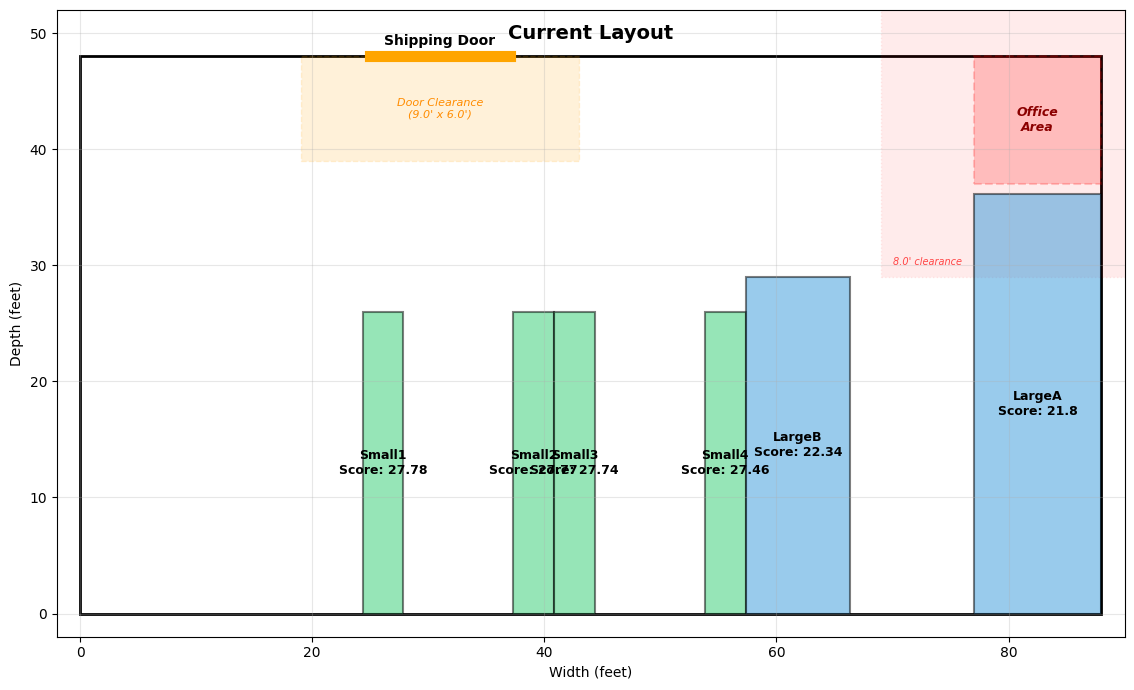

In [75]:
print("\nAnalyzing current layout...\n")

# Extract shelf dimensions
shelf_dims = {}
for name, (x1, x2, y1, y2, t) in current_shelves.items():
    shelf_dims[name] = (x2 - x1, y2 - y1)

# Score current layout
current_rows = []
for name, (x1, x2, y1, y2, shelf_type) in current_shelves.items():
    score, dist, loses_face = compute_value_score(name, x1, x2, y1, y2, shelf_type)
    left, right, bottom, top = touches_wall_rect(x1, x2, y1, y2)
    cx, cy = center_from_rect(x1, x2, y1, y2)
    
    current_rows.append({
        "Shelf": name,
        "Type": shelf_type,
        "x1": x1, "x2": x2, "y1": y1, "y2": y2,
        "CenterX": round(cx, 2),
        "CenterY": round(cy, 2),
        "DistToDoor": dist,
        "TouchesWalls": f"L:{left},R:{right},B:{bottom},T:{top}",
        "LosesFace": loses_face,
        "ValueScore": score
    })

df_current = pd.DataFrame(current_rows).sort_values("ValueScore", ascending=False).reset_index(drop=True)
current_total = df_current['ValueScore'].sum()

print(f"✓ Current Layout Analysis Complete")
print(f"  Total Value Score: {current_total:.2f}\n")
print("Current Layout Details:")
display(df_current)

# Visualize current layout
draw_layout(df_current.to_dict('records'), "Current Layout", "current_layout.png")


In [76]:
print("\nGenerating candidate positions on grid (with rotations)...\n")

possible_positions = {}
for shelf_name, (length, depth) in shelf_dims.items():
    possible_positions[shelf_name] = generate_positions_for_dim(length, depth, allow_rotation=True)
    
    # Count rotations
    rotations_0 = sum(1 for pos in possible_positions[shelf_name] if pos[4] == 0)
    rotations_90 = sum(1 for pos in possible_positions[shelf_name] if pos[4] == 90)
    
    print(f"  {shelf_name}: {len(possible_positions[shelf_name])} candidate positions")
    print(f"    - 0° rotation: {rotations_0} positions")
    print(f"    - 90° rotation: {rotations_90} positions")

total_candidates = sum(len(v) for v in possible_positions.values())
print(f"\n✓ Total candidate positions: {total_candidates:,}")


Generating candidate positions on grid (with rotations)...

  LargeA: 75 candidate positions
    - 0° rotation: 35 positions
    - 90° rotation: 40 positions
  LargeB: 94 candidate positions
    - 0° rotation: 49 positions
    - 90° rotation: 45 positions
  Small1: 133 candidate positions
    - 0° rotation: 72 positions
    - 90° rotation: 61 positions
  Small2: 133 candidate positions
    - 0° rotation: 72 positions
    - 90° rotation: 61 positions
  Small3: 133 candidate positions
    - 0° rotation: 72 positions
    - 90° rotation: 61 positions
  Small4: 133 candidate positions
    - 0° rotation: 72 positions
    - 90° rotation: 61 positions

✓ Total candidate positions: 701


In [77]:
print("Building optimization model with rotation support...")

model = LpProblem("warehouse_layout_opt_rotated", LpMaximize)

# Decision variables (now includes rotation info)
x = {}
for s in possible_positions:
    for p_idx in range(len(possible_positions[s])):
        x[(s, p_idx)] = LpVariable(f"x_{s}_{p_idx}", cat=LpBinary)

print(f"  Created {len(x)} decision variables")

# Objective: maximize total value score
def score_for_candidate(s, pos):
    x1, x2, y1, y2, rotation = pos
    shelf_type = current_shelves[s][4]
    score, _, _ = compute_value_score(s, x1, x2, y1, y2, shelf_type)
    return score

model += lpSum(score_for_candidate(s, possible_positions[s][p_idx]) * x[(s, p_idx)]
               for s in possible_positions for p_idx in range(len(possible_positions[s])))

print("  ✓ Objective function defined")

# Constraint: each shelf placed exactly once
for s in possible_positions:
    model += lpSum(x[(s, p_idx)] for p_idx in range(len(possible_positions[s]))) == 1

print(f"  ✓ Added {len(possible_positions)} placement constraints")

# Constraint: no overlaps
print("  Adding non-overlap constraints...")
constraint_count = 0
shelf_list = list(possible_positions.keys())
for i in range(len(shelf_list)):
    for j in range(i + 1, len(shelf_list)):
        s1 = shelf_list[i]
        s2 = shelf_list[j]
        for p_idx, pos1 in enumerate(possible_positions[s1]):
            for q_idx, pos2 in enumerate(possible_positions[s2]):
                if overlap(pos1, pos2):
                    model += x[(s1, p_idx)] + x[(s2, q_idx)] <= 1
                    constraint_count += 1

print(f"  ✓ Added {constraint_count:,} non-overlap constraints")

# Constraint: minimum spacing between shelves
print(f"  Adding minimum spacing constraints ({MIN_SHELF_SPACING}' between shelves)...")
spacing_count = 0
for i in range(len(shelf_list)):
    for j in range(i + 1, len(shelf_list)):
        s1 = shelf_list[i]
        s2 = shelf_list[j]
        for p_idx, pos1 in enumerate(possible_positions[s1]):
            for q_idx, pos2 in enumerate(possible_positions[s2]):
                dist = min_distance_between_shelves(pos1, pos2)
                if 0 < dist < MIN_SHELF_SPACING:
                    model += x[(s1, p_idx)] + x[(s2, q_idx)] <= 1
                    spacing_count += 1

print(f"  ✓ Added {spacing_count:,} minimum spacing constraints")

print("\n⏳ Solving ILP (this may take longer with rotations)...")
solver_status = model.solve(PULP_CBC_CMD(msg=1, timeLimit=180))  # Increased time limit
print(f"\n✓ Solver completed")
print(f"  Status code: {solver_status}")
print(f"  Status: {model.status}")

if model.status != 1:
    print(f"\n⚠️ SOLVER FAILED TO FIND OPTIMAL SOLUTION!")
    print(f"  Status code meanings: 1=Optimal, 0=Not Solved, -1=Infeasible, -2=Unbounded")
else:
    print(f"  ✓ Solver found optimal solution")

Building optimization model with rotation support...
  Created 701 decision variables
  ✓ Objective function defined
  ✓ Added 6 placement constraints
  Adding non-overlap constraints...
  ✓ Added 47,580 non-overlap constraints
  Adding minimum spacing constraints (8.0' between shelves)...
  ✓ Added 27,768 minimum spacing constraints

⏳ Solving ILP (this may take longer with rotations)...

✓ Solver completed
  Status code: 1
  Status: 1
  ✓ Solver found optimal solution



EXTRACTING OPTIMAL SOLUTION (WITH ROTATIONS)

✓ Optimal Layout Found
  Current Total Score: 154.89
  Optimal Total Score: 164.57
  Improvement: +9.68 (6.2%)

📐 Rotated Shelves (90°): 1
  - LargeA: large

Optimized Layout Details:


,Shelf,Type,x1,x2,y1,y2,Rotation,CenterX,CenterY,DistToDoor,TouchesWalls,LosesFace,ValueScore
0,Small2,small,44.0,47.500,22.0,48.0,0,45.75,35.0,15.67,"L:False,R:False,B:False,T:True",False,31.00
1,Small4,small,14.0,17.500,22.0,48.0,0,15.75,35.0,15.96,"L:False,R:False,B:False,T:True",False,30.90
2,Small1,small,56.0,59.500,22.0,48.0,0,57.75,35.0,24.49,"L:False,R:False,B:False,T:True",False,28.92
3,Small3,small,2.0,5.500,22.0,48.0,0,3.75,35.0,24.91,"L:False,R:False,B:False,T:True",False,28.86
4,LargeB,large,26.0,35.000,0.0,29.0,0,30.50,14.5,33.50,"L:False,R:False,B:True,T:False",True,22.90
5,LargeA,large,44.0,80.167,0.0,11.0,90,62.08,5.5,49.35,"L:False,R:False,B:True,T:False",True,21.99


✓ Saved: optimized_layout_rotated.png


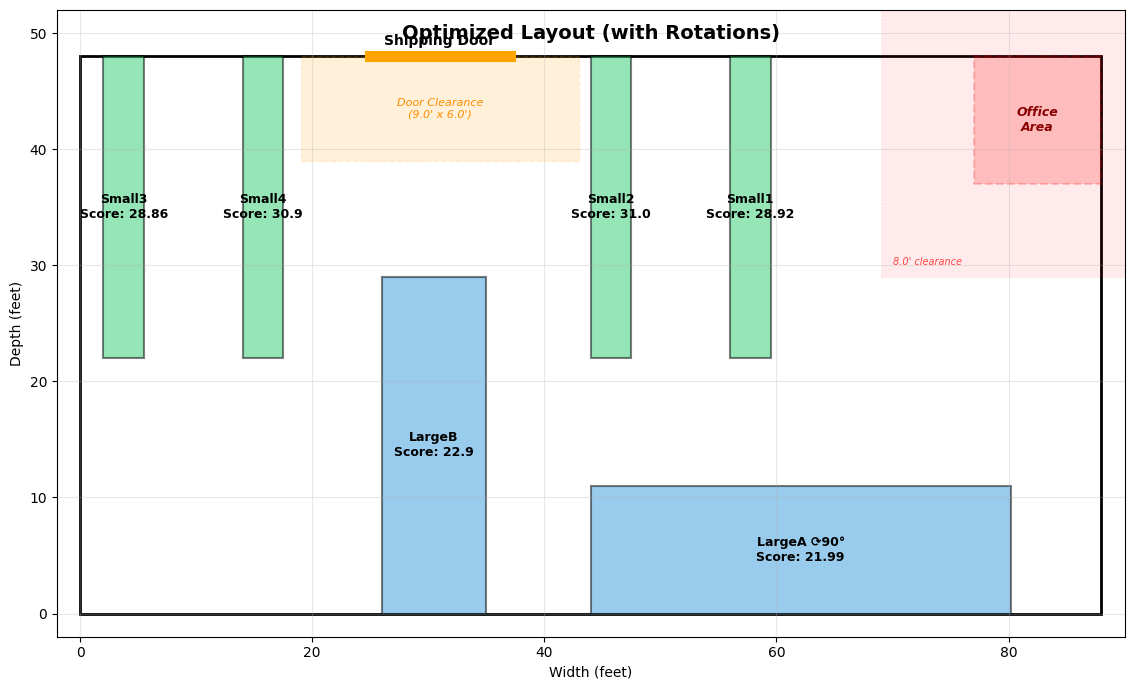


✓ OPTIMIZATION COMPLETE


In [78]:
print("\n" + "="*70)
print("EXTRACTING OPTIMAL SOLUTION (WITH ROTATIONS)")
print("="*70 + "\n")

optimal_rows = []
opt_positions = {}

for s in possible_positions:
    chosen = []
    for p_idx in range(len(possible_positions[s])):
        var_value = x[(s, p_idx)].varValue
        if var_value and var_value > 0.5:
            chosen.append(p_idx)
    
    if not chosen:
        print(f"  ⚠️ {s}: No position selected - using current")
        opt_pos = (current_shelves[s][0], current_shelves[s][1], 
                  current_shelves[s][2], current_shelves[s][3], 0)
    elif len(chosen) > 1:
        print(f"  ⚠️ {s}: Multiple positions selected - using first")
        opt_pos = possible_positions[s][chosen[0]]
    else:
        opt_pos = possible_positions[s][chosen[0]]
    
    opt_positions[s] = opt_pos
    x1, x2, y1, y2, rotation = opt_pos
    shelf_type = current_shelves[s][4]
    score, dist, loses_face = compute_value_score(s, x1, x2, y1, y2, shelf_type)
    cx, cy = center_from_rect(x1, x2, y1, y2)
    left, right, bottom, top = touches_wall_rect(x1, x2, y1, y2)
    
    optimal_rows.append({
        "Shelf": s,
        "Type": shelf_type,
        "x1": x1, "x2": x2, "y1": y1, "y2": y2,
        "Rotation": rotation,
        "CenterX": round(cx, 2),
        "CenterY": round(cy, 2),
        "DistToDoor": dist,
        "TouchesWalls": f"L:{left},R:{right},B:{bottom},T:{top}",
        "LosesFace": loses_face,
        "ValueScore": score
    })

df_optimal = pd.DataFrame(optimal_rows).sort_values("ValueScore", ascending=False).reset_index(drop=True)
optimal_total = df_optimal['ValueScore'].sum()

print(f"✓ Optimal Layout Found")
print(f"  Current Total Score: {current_total:.2f}")
print(f"  Optimal Total Score: {optimal_total:.2f}")
print(f"  Improvement: +{optimal_total - current_total:.2f} ({((optimal_total - current_total)/current_total * 100):.1f}%)\n")

# Show rotation summary
rotated_shelves = df_optimal[df_optimal['Rotation'] == 90]
if len(rotated_shelves) > 0:
    print(f"📐 Rotated Shelves (90°): {len(rotated_shelves)}")
    for _, row in rotated_shelves.iterrows():
        print(f"  - {row['Shelf']}: {row['Type']}")
    print()

print("Optimized Layout Details:")
display(df_optimal)

# Visualize optimal layout
draw_layout(df_optimal.to_dict('records'), "Optimized Layout (with Rotations)", "optimized_layout_rotated.png")

print("\n✓ OPTIMIZATION COMPLETE")